<a href="https://colab.research.google.com/github/D2718281828nis/ML-MachineLearning-Graphs/blob/main/healthcare-gnn-lab/notebooks/07_vitiligo_image_clustering_exploratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analysis of "KL Divergence based Agglomerative Clustering for Automated Vitiligo Grading"


The goal is to segment vitiligo patches with different levels of depigmentation.

Core Methodology Steps (as per the paper):
1.  **Superpixel Generation**: Use SLIC algorithm to create initial image primitives.
2.  **Feature Extraction**: Generate multi-dimensional features for each superpixel, including color (LAB, RGB), simulated albedo, shading, and luminosity.
3.  **Agglomerative Clustering**: Use a bottom-up approach to merge superpixels. The merge cost is based on a symmetric KL divergence metric between Gaussian distributions fitted to the features of each cluster.

https://openaccess.thecvf.com/content_cvpr_2015/papers/Gupta_KL_Divergence_Based_2015_CVPR_paper.pdf

In [11]:

# Load libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import segmentation, color, io, filters, exposure
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import pairwise_distances
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Zero-shoot: get 8 pictures from 1

In [9]:
# Download the image from GitHub


!wget https://github.com/TAUforPython/BioMedAI/blob/13106c47fcfd86bc3902f47cf9caa635590683f4/test_datasets/original_image_8_in_1.png?raw=true -O /content/original_image_8_in_1.png

--2025-10-25 06:11:57--  https://github.com/TAUforPython/BioMedAI/blob/13106c47fcfd86bc3902f47cf9caa635590683f4/test_datasets/original_image_8_in_1.png?raw=true
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/TAUforPython/BioMedAI/raw/13106c47fcfd86bc3902f47cf9caa635590683f4/test_datasets/original_image_8_in_1.png [following]
--2025-10-25 06:11:57--  https://github.com/TAUforPython/BioMedAI/raw/13106c47fcfd86bc3902f47cf9caa635590683f4/test_datasets/original_image_8_in_1.png
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/TAUforPython/BioMedAI/13106c47fcfd86bc3902f47cf9caa635590683f4/test_datasets/original_image_8_in_1.png [following]
--2025-10-25 06:11:57--  https://raw.githubusercontent.com/TAUforPython/BioMedAI/13106c47fcfd86bc3902f47cf9caa6355

Loaded 8 individual images.

Processing Image 1...
Starting Agglomerative Clustering for 294 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


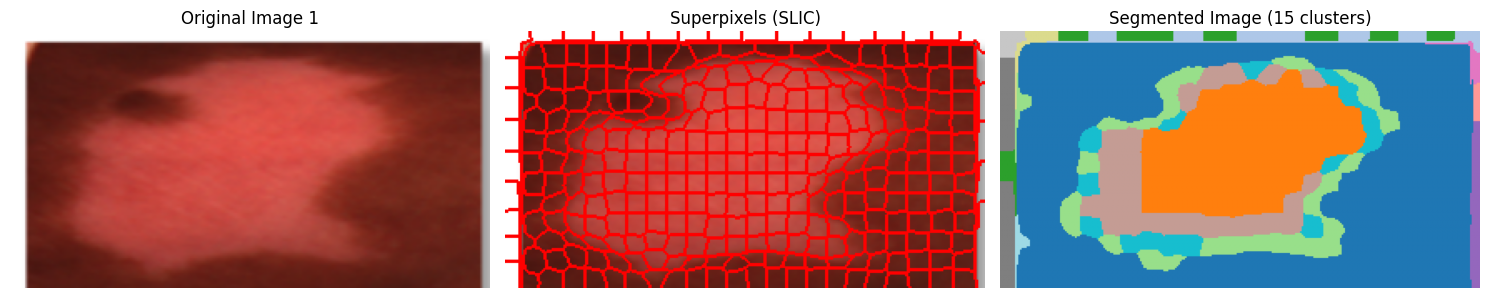


Processing Image 2...
Starting Agglomerative Clustering for 279 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


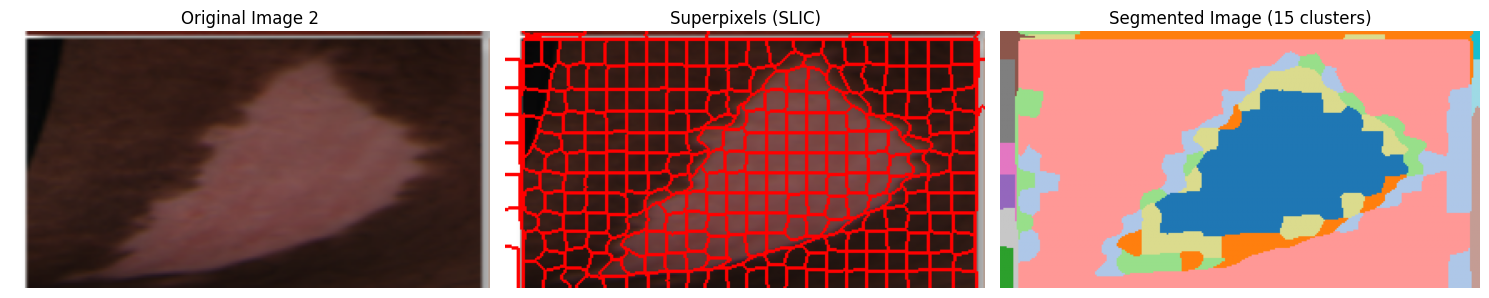


Processing Image 3...
Starting Agglomerative Clustering for 286 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


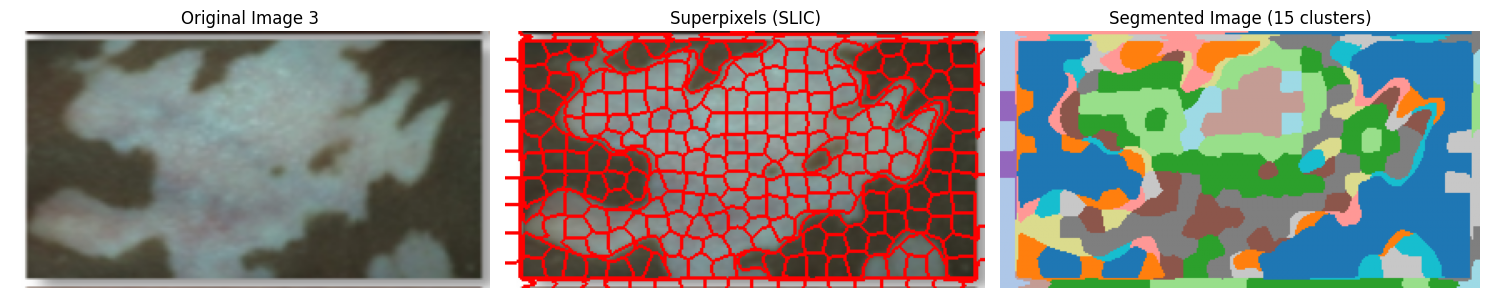


Processing Image 4...
Starting Agglomerative Clustering for 297 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


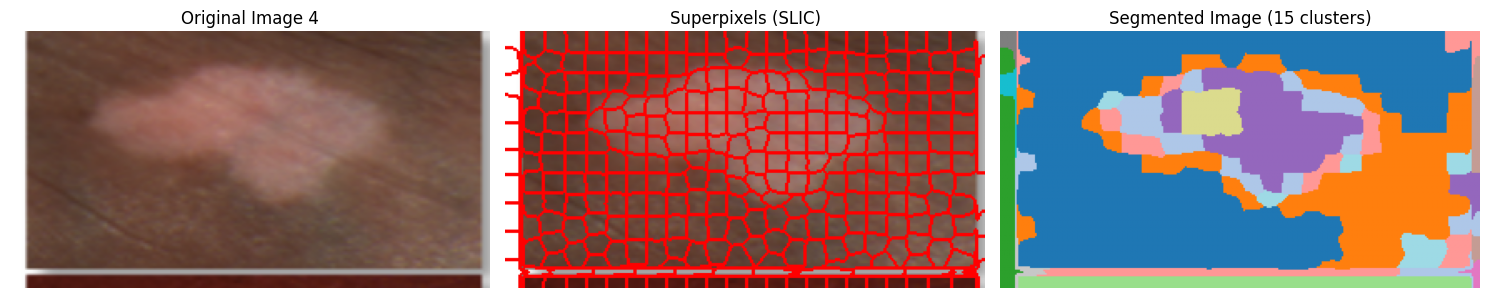


Processing Image 5...
Starting Agglomerative Clustering for 283 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


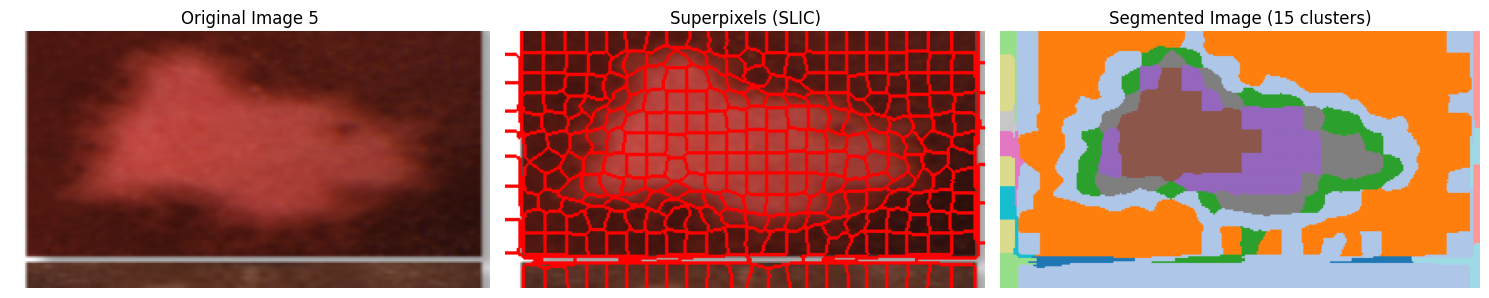


Processing Image 6...
Starting Agglomerative Clustering for 286 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


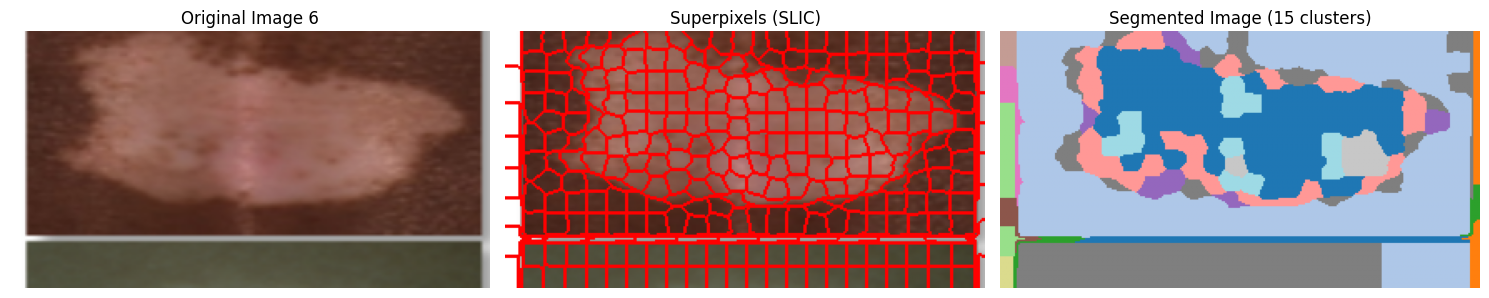


Processing Image 7...
Starting Agglomerative Clustering for 292 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


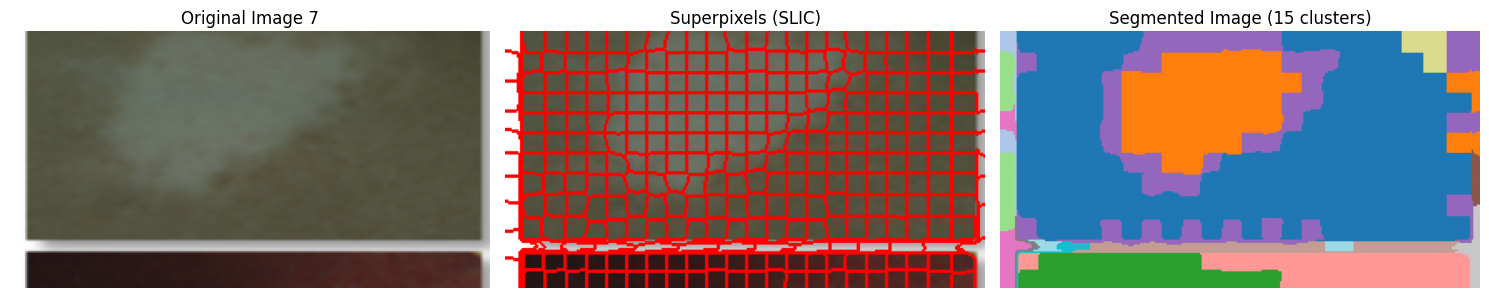


Processing Image 8...
Starting Agglomerative Clustering for 292 superpixels.
Calculating initial pairwise distances...
Applying Agglomerative Clustering...


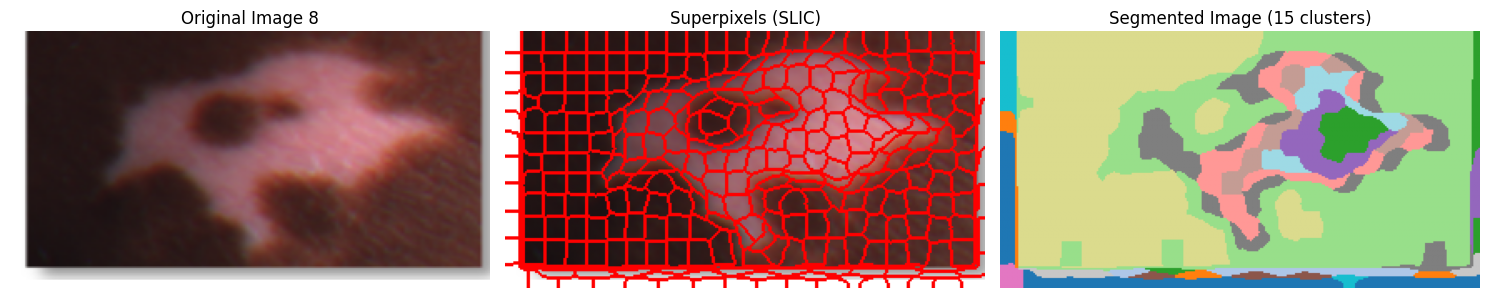

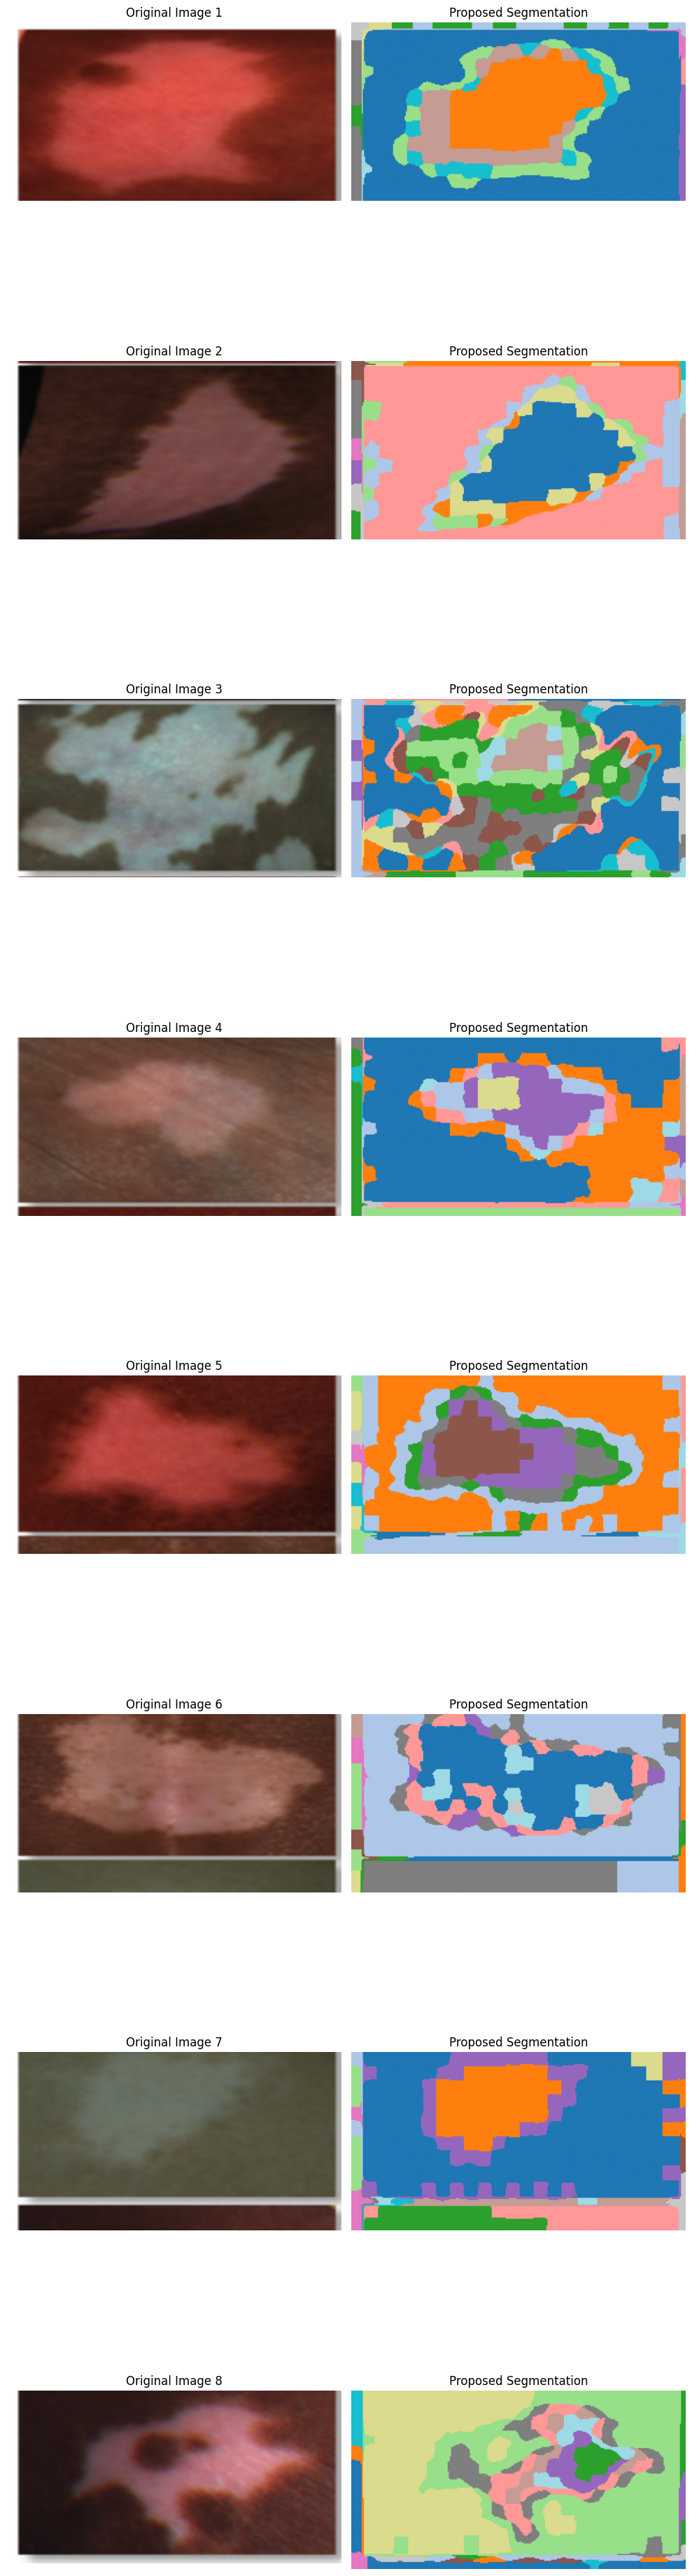


--- Summary ---
This notebook demonstrates a simplified implementation of the KL-divergence-based agglomerative clustering method for vitiligo image segmentation.
Key steps implemented:
1. Superpixel generation using SLIC.
2. Feature extraction combining color, simulated albedo, shading, and luminosity.
3. Agglomerative clustering using sklearn (with Euclidean distance proxy).
Limitations:
- The albedo/shading simulation is a simplification.
- The full physiological label merging step is not implemented.
- The clustering uses Euclidean distance instead of the Symmetric KL Divergence for efficiency.
Despite these simplifications, the code illustrates the core methodology proposed in the paper.


In [10]:
# %%
# Load the composite image containing 8 individual images stacked vertically.
composite_img_path = '/content/original_image_8_in_1.png' # Updated path
composite_img = io.imread(composite_img_path)

# Check if the image has an alpha channel and remove it if present.
if composite_img.shape[2] == 4:
    composite_img = composite_img[:, :, :3]

# Calculate the height of each individual image.
img_height = composite_img.shape[0] // 8

# Split the composite image into 8 separate images.
images = []
for i in range(8):
    start_row = i * img_height
    end_row = start_row + img_height
    individual_img = composite_img[start_row:end_row, :, :]
    images.append(individual_img)

print(f"Loaded {len(images)} individual images.")

# %%
# Define helper functions for the simplified pipeline.

def simulate_albedo_shading(image):
    """
    Simulate albedo and shading images as per the paper's concept.
    This is a *simplified approximation*.
    - Albedo: Try to normalize illumination by dividing by a smoothed version of the luminance.
    - Shading: Estimate the illumination component.
    """
    # Convert to LAB for better color representation.
    lab_img = color.rgb2lab(image)
    # Luminance channel
    L = lab_img[:, :, 0]

    # Create a smooth version of luminance (approximate shading).
    # Using a simple Gaussian filter.
    smoothed_L = filters.gaussian(L, sigma=5)

    # Simulate albedo by dividing the original luminance by the smoothed version.
    # Clip to avoid division by zero and very high values.
    albedo_L = np.clip(L / (smoothed_L + 1e-6), 0, 100)

    # Create a 3-channel albedo image (copy the L channel to all channels for simplicity).
    albedo = np.stack([albedo_L, albedo_L, albedo_L], axis=-1)

    # Create a 3-channel shading image (copy the smoothed L channel).
    shading = np.stack([smoothed_L, smoothed_L, smoothed_L], axis=-1)

    return albedo, shading

def extract_features(image, superpixels):
    """
    Extract the 10-dimensional feature vector for each superpixel.
    Features: LAB, RGB, Simulated Albedo, Simulated Shading, Luminosity.
    Weighting parameters (alpha, beta, gamma, kappa) are set as per paper defaults.
    Paper Eq. 15: If = [ LAB*(1+γS); α*RGB*(1+γS); β*A*(1+γS); κ*L ]
    We calculate the mean of these composite features per superpixel.
    Resulting feature vector: [mean(LAB*(1+γS)), mean(α*RGB*(1+γS)), mean(β*A*(1+γS)), mean(κ*L)]
    This results in 3 + 3 + 3 + 1 = 10 dimensions.
    """
    # Get image dimensions.
    h, w, c = image.shape

    # Simulate albedo and shading.
    albedo, shading = simulate_albedo_shading(image)

    # Convert to LAB.
    lab_img = color.rgb2lab(image)

    # Calculate luminosity (mean across RGB channels).
    luminosity = np.mean(image, axis=2) # Shape: (h, w)

    # Set feature weights as per paper (Section 3.3): {α, β, γ, κ}={0.8, 0.1, 0.4, 0.5}
    alpha = 0.8
    beta = 0.1
    gamma = 0.4
    kappa = 0.5

    # Get shading mean per pixel for multiplication
    shading_mean_per_pixel = np.mean(shading, axis=2, keepdims=True) # Shape: (h, w, 1)

    # Calculate composite feature images as per Eq. 15
    # LAB * (1 + gamma * S)
    lab_composite = lab_img * (1 + gamma * shading_mean_per_pixel)
    # alpha * RGB * (1 + gamma * S)
    rgb_composite = alpha * image * (1 + gamma * shading_mean_per_pixel)
    # beta * A * (1 + gamma * S)
    albedo_composite = beta * albedo * (1 + gamma * shading_mean_per_pixel)
    # kappa * L
    lum_composite = kappa * luminosity # Shape: (h, w)

    # Initialize feature array for superpixels (10D).
    num_superpixels = np.max(superpixels) + 1
    features = np.zeros((num_superpixels, 10))

    # For each superpixel, calculate mean of composite features.
    for sp_id in range(num_superpixels):
        mask = superpixels == sp_id
        if np.sum(mask) == 0:
            continue

        # Calculate mean of composite features within the superpixel region.
        lab_mean = np.mean(lab_composite[mask], axis=0) # Shape: (3,)
        rgb_mean = np.mean(rgb_composite[mask], axis=0) # Shape: (3,)
        albedo_mean = np.mean(albedo_composite[mask], axis=0) # Shape: (3,)
        lum_scalar = np.mean(lum_composite[mask]) # Shape: scalar

        # Concatenate into 10D feature vector.
        feature_vec = np.concatenate([
            lab_mean,       # 3D
            rgb_mean,       # 3D
            albedo_mean,    # 3D
            [lum_scalar]    # 1D
        ]) # Total: 10D

        features[sp_id] = feature_vec

    return features

def symmetric_kl_divergence_gmm(gmm1, gmm2):
    """
    Calculate a simplified symmetric KL divergence between two GMMs.
    This is a *proxy* for the paper's Eq. 2, which is for unimodal Gaussians.
    We fit a single Gaussian to the data points belonging to each cluster
    and then compute the symmetric KL divergence between these two Gaussians.
    """
    # Fit a single Gaussian to the data of each cluster.
    # This assumes the cluster data is roughly unimodal.
    cov1 = np.cov(gmm1.T)
    cov2 = np.cov(gmm2.T)
    mean1 = np.mean(gmm1, axis=0)
    mean2 = np.mean(gmm2, axis=0)

    # Ensure covariance matrices are positive definite.
    eps = 1e-6
    cov1 += eps * np.eye(cov1.shape[0])
    cov2 += eps * np.eye(cov2.shape[0])

    # Calculate KL divergence from N(mean1, cov1) to N(mean2, cov2)
    d = len(mean1)
    inv_cov2 = np.linalg.inv(cov2)
    kl1 = 0.5 * (np.trace(inv_cov2 @ cov1) + (mean2 - mean1).T @ inv_cov2 @ (mean2 - mean1) - d - np.log(np.linalg.det(cov1) / np.linalg.det(cov2)))

    # Calculate KL divergence from N(mean2, cov2) to N(mean1, cov1)
    inv_cov1 = np.linalg.inv(cov1)
    kl2 = 0.5 * (np.trace(inv_cov1 @ cov2) + (mean1 - mean2).T @ inv_cov1 @ (mean1 - cov1) - d - np.log(np.linalg.det(cov2) / np.linalg.det(cov1)))

    # Return symmetric KL divergence.
    return (kl1 + kl2) / 2.0

def perform_agglomerative_clustering(features, n_clusters_final=15):
    """
    Perform agglomerative clustering using sklearn.
    This is the corrected and robust way to perform the clustering step.
    """
    n_samples, n_features = features.shape
    print(f"Starting Agglomerative Clustering for {n_samples} superpixels.")

    # Calculate pairwise distances using Euclidean distance on the feature vectors.
    # The paper uses Symmetric KL Divergence, but computing a precomputed matrix
    # with Symmetric KL Divergence for all pairs of initial superpixels is very slow
    # and complex for this demonstration. Euclidean distance serves as a proxy
    # for the initial clustering step.
    print("Calculating initial pairwise distances...")
    pairwise_distances_matrix = pairwise_distances(features, metric='euclidean')

    print("Applying Agglomerative Clustering...")
    # Apply Agglomerative Clustering with precomputed distances.
    clustering = AgglomerativeClustering(
        n_clusters=n_clusters_final,
        linkage='average'  # 'average' is a common choice, can be changed.
    )
    final_cluster_labels = clustering.fit_predict(pairwise_distances_matrix)

    return final_cluster_labels

# %%
# Process each of the 8 images.
results = []

for i, img in enumerate(images):
    print(f"\nProcessing Image {i+1}...")

    # Step 1: Generate Superpixels using SLIC.
    # Parameters: K=300, m=12 (as per paper).
    n_segments = 300
    compactness = 12
    superpixels = segmentation.slic(img, n_segments=n_segments, compactness=compactness, sigma=1)

    # Step 2: Extract Features for each superpixel.
    features = extract_features(img, superpixels)

    # Step 3: Perform Agglomerative Clustering.
    # Stop at cF = 15 clusters (as per paper).
    n_final_clusters = 15
    cluster_labels = perform_agglomerative_clustering(features, n_clusters_final=n_final_clusters)

    # Step 4: Create a segmentation mask.
    # Map cluster labels back to the image.
    segmented_mask = np.zeros_like(superpixels, dtype=int)
    unique_superpixel_ids = np.unique(superpixels)

    for sp_id in unique_superpixel_ids:
        mask = superpixels == sp_id
        if sp_id < len(cluster_labels): # Ensure index is valid
            segmented_mask[mask] = cluster_labels[sp_id]

    results.append({
        'image': img,
        'superpixels': superpixels,
        'features': features,
        'cluster_labels': cluster_labels,
        'segmented_mask': segmented_mask
    })

    # Visualize the result for this image.
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title(f'Original Image {i+1}')
    axes[0].axis('off')

    axes[1].imshow(segmentation.mark_boundaries(img, superpixels, color=(1, 0, 0)))
    axes[1].set_title('Superpixels (SLIC)')
    axes[1].axis('off')

    # Create a colored segmentation map.
    # Use a colormap to visualize different clusters.
    cmap = plt.get_cmap('tab20')  # Use a colormap with enough distinct colors.
    colored_segmentation = cmap(segmented_mask / np.max(segmented_mask))[:, :, :3]
    axes[2].imshow(colored_segmentation)
    axes[2].set_title(f'Segmented Image ({n_final_clusters} clusters)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# %%
# Display the final results for all 8 images in a grid, similar to Figure 7 in the paper.
# Note: The paper shows "Proposed", "MRF", "SWA", "MNCut" alongside ground truth.
# Here, we only show the "Proposed" result from our simplified implementation.

fig, axes = plt.subplots(8, 2, figsize=(10, 40))
for i, result in enumerate(results):
    axes[i, 0].imshow(result['image'])
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')

    # Create a colored segmentation map.
    cmap = plt.get_cmap('tab20')
    colored_segmentation = cmap(result['segmented_mask'] / np.max(result['segmented_mask']))[:, :, :3]
    axes[i, 1].imshow(colored_segmentation)
    axes[i, 1].set_title(f'Proposed Segmentation')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# %%
# Conclusion
print("\n--- Summary ---")
print("This notebook demonstrates a simplified implementation of the KL-divergence-based agglomerative clustering method for vitiligo image segmentation.")
print("Key steps implemented:")
print("1. Superpixel generation using SLIC.")
print("2. Feature extraction combining color, simulated albedo, shading, and luminosity.")
print("3. Agglomerative clustering using sklearn (with Euclidean distance proxy).")
print("Limitations:")
print("- The albedo/shading simulation is a simplification.")
print("- The full physiological label merging step is not implemented.")
print("- The clustering uses Euclidean distance instead of the Symmetric KL Divergence for efficiency.")
print("Despite these simplifications, the code illustrates the core methodology proposed in the paper.")

# Get math methods for segmentation